<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/Insight-Sogang-Univ/insight-15th/blob/main/advanced/template/session07/assignment_recsys.ipynb" target="_parent">
      <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
  </td>
</table>

# <span style="color:black; background-color:#F5F5F5;"> 🍀 **추천 시스템 (Recommendation System) 과제** </span>

## **1. 추천 시스템 기본 개념**

### 1-1. 빈칸에 들어갈 말을 순서대로 작성해주세요.
자카드 유사도는 아이템 집합간의 OOO 크기를 이용하여 측정
<br>코사인 유사도는 아이템의 벡터 사이의 OO를 이용하여 측정
<br>유클리디안 거리는 아이템의 벡터 사이의 OO를 이용하여 측정
<br>피어슨 상관계수는 아이템의 벡터간 OO OO OO를 이용하여 측정

답:교집합, 각도, 거리, 선형 상관 관계

### 1-2. T/F를 골라주시고, **F일 경우 이유까지** 함께 작성해주세요.
(1) 평갓값 행렬은 수집한 사용자의 아이템 선호도를 정량적으로 나타낸 것으로, 사용자 X 아이템으로 계산한다. 이렇게 발견된 평점은 밀집 행렬의 형태를 띄고 있어 명시되지 않은 평점을 대체하는 것이 가능하다<br>

(2) 연관 분석 규칙 생성은 가능한 모든 경우의 수를 탐색해 평가지표가 높은 규칙을 찾는 방식으로, 사용자 수가 증가할수록 규칙 수가 기하급수적으로 증가한다는 문제점이 있다.<br>

(3) Memory-based는 모든 데이터를 이용하기에, 항상 최신 데이터를 반영해 추천 가능하지만, 매번 모든 데이터에서 비슷한 user나 item을 찾아야 해서 오래 걸린다.

답:
(1) F. 평점 행렬은 대부분의 사용자가 모든 아이템을 평가하지 않으므로 희소행렬. 따라서 바로 대체가 아닌 추천 알고리즘 통해 예측해야함       
(2) F. 연관 분석 규칙은 가능한 아이템 조합 바로 탐색하므로, 규칙 수가 증가하는 원인은 아이템 수의 증가이다.           
(3) T

---

우선, 두 가지 방법의 협업 필터링을 구현해 보려고 합니다!  
(내용 기반 필터링은 실습에서 했으니까요)

## **2. Item-Based Collaborative Filtering**

---

In [1]:
import pandas as pd
import numpy as np

In [3]:
ratings= pd.read_csv("chicken_1415th.csv", index_col='이름') # 파일 불러오기
ratings

,(BHC) 뿌링클,(BHC) 맛초킹,(BHC) 레드킹,(교촌) 교촌콤보,(교촌) 허니콤보,(교촌) 레드콤보,(굽네) 고추바사삭,(굽네) 볼케이노,(굽네) 갈비천왕,(BBQ) 황금올리브,...,(60계) 간지치킨,(바른치킨) 대세레드,(바른치킨) 현미바사삭,(바른치킨) 통곡물간장,(노랑통닭) 알싸한마늘치킨,(노랑통닭) 뿌리노랑치킨,(노랑통닭) 칼칼한청양치킨,(후참잘) 후라이드치킨,(후참잘) 양념치킨,(후참잘) 간장치킨]
이름,,,,,,,,,,,,,,,,,,,,,
권도영,4.0,3.0,3.0,5.0,5.0,4.0,5.0,2.0,2.0,5.0,...,0.0,0.0,4.0,4.0,4.0,0.0,0.0,4.0,1.0,4.0
고유빈,3.0,2.0,1.0,3.0,3.0,3.0,3.0,1.0,0.0,3.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
구준모,3.0,0.0,0.0,5.0,2.0,3.0,5.0,5.0,4.0,5.0,...,5.0,3.0,4.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0
권유철,5.0,2.0,3.0,5.0,5.0,3.0,2.0,3.0,2.0,5.0,...,0.0,1.0,4.0,5.0,5.0,0.0,0.0,5.0,4.0,3.0
김민아,5.0,5.0,2.0,3.0,5.0,5.0,5.0,4.0,4.0,5.0,...,4.0,3.0,3.0,3.0,5.0,3.0,2.0,2.0,2.0,2.0
김지윤,3.0,3.0,0.0,0.0,2.0,1.0,3.0,0.0,3.0,3.0,...,3.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
김진하,2.0,0.0,0.0,4.0,4.0,3.0,5.0,0.0,0.0,5.0,...,0.0,0.0,3.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0
김태희,1.0,0.0,0.0,0.0,1.0,0.0,4.0,4.0,0.0,5.0,...,1.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
김희연,1.0,0.0,0.0,3.0,4.0,3.0,4.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,3.0,3.0,0.0,4.0,0.0,0.0


### **2-1. 아이템 유사도 계산**

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

# 유사도 계산을 위해 결측치를 0으로 대체
ratings.fillna(0, inplace=True)

# 유사도 계산
item_similarity = cosine_similarity(ratings.T)

# 아이템 유사도 DataFrame 생성
# data는 item_similarity, index는 ratings.T.index, columns는 ratings.T.index로 지정합니다.
item_similarity = pd.DataFrame(data=item_similarity,
                            index=ratings.T.index,
                            columns=ratings.T.index)

item_similarity.head()

,(BHC) 뿌링클,(BHC) 맛초킹,(BHC) 레드킹,(교촌) 교촌콤보,(교촌) 허니콤보,(교촌) 레드콤보,(굽네) 고추바사삭,(굽네) 볼케이노,(굽네) 갈비천왕,(BBQ) 황금올리브,...,(60계) 간지치킨,(바른치킨) 대세레드,(바른치킨) 현미바사삭,(바른치킨) 통곡물간장,(노랑통닭) 알싸한마늘치킨,(노랑통닭) 뿌리노랑치킨,(노랑통닭) 칼칼한청양치킨,(후참잘) 후라이드치킨,(후참잘) 양념치킨,(후참잘) 간장치킨]
(BHC) 뿌링클,1.000000,0.689363,0.623440,0.856836,0.872469,0.806401,0.780076,0.728011,0.734909,0.887981,...,0.550795,0.644712,0.822226,0.688165,0.724254,0.495715,0.527945,0.704225,0.627324,0.663856
(BHC) 맛초킹,0.689363,1.000000,0.739734,0.583333,0.637382,0.699452,0.637059,0.530769,0.595876,0.658184,...,0.589256,0.640464,0.565871,0.450625,0.748370,0.466690,0.542218,0.586858,0.542326,0.675053
(BHC) 레드킹,0.623440,0.739734,1.000000,0.565916,0.648817,0.668060,0.519152,0.466415,0.491774,0.551251,...,0.385872,0.382364,0.527862,0.623159,0.724192,0.565945,0.532291,0.548178,0.578747,0.600323
(교촌) 교촌콤보,0.856836,0.583333,0.565916,1.000000,0.912391,0.852823,0.818267,0.688034,0.602313,0.870739,...,0.419026,0.569301,0.862511,0.680768,0.697134,0.384980,0.372954,0.709341,0.548352,0.587546
(교촌) 허니콤보,0.872469,0.637382,0.648817,0.912391,1.000000,0.872572,0.841738,0.651339,0.646862,0.865773,...,0.372839,0.595942,0.806678,0.765037,0.706897,0.578997,0.372387,0.678888,0.524811,0.570548


### 본격적인 시작에 앞서, 여러분이 마케팅팀이라고 가정했을 때, 교촌 허니콤보와 유사한 선호도를 가진 치킨끼리 묶어서 특가 할인행사를 시행하려고 합니다!<br>
# 유사한 선호도 Top 3를 묶어서 특가 할인행사 대상을 선별해주세요!

#### **2-1-1. 특가 할인행사 대상은 어떻게 도출되었나요?**

답:허니콤보와 다른 치킨들의 코사인 유사도를 계산하고, 유사도 값이 가장 높은 상위 3개 치킨을 특가 할인 대상으로 선별함

In [5]:
def get_similar_item(title):
    return item_similarity[title].sort_values(ascending=False)[1:4]

get_similar_item("(교촌) 허니콤보").head(3)

,(교촌) 허니콤보
(교촌) 교촌콤보,0.912391
(교촌) 레드콤보,0.872572
(BHC) 뿌링클,0.872469


#### **2-1-2. 각 치킨별 추천 치킨(아이템 유사도 기준) 만들기**

In [6]:
# 치킨 리스트
chicken_list = list(item_similarity.index)

# 새로운 데이터프레임을 만들기 위한 빈 리스트 초기화
recommendations = []

# 각 치킨에 대해 유사한 항목 찾기
for chicken in chicken_list:
    similar_items = get_similar_item(chicken).head(3)

    # '추천 치킨'이라는 새로운 칼럼을 만들어 데이터프레임에 추가
    recommendations.append({
        'Chicken': chicken,
        'Recommendations': ', '.join(similar_items.index)
    })

# 결과 데이터프레임 생성
result_df = pd.DataFrame(recommendations)

# 결과 출력
result_df

,Chicken,Recommendations
0,(BHC) 뿌링클,"(BBQ) 황금올리브, (교촌) 허니콤보, (교촌) 교촌콤보"
1,(BHC) 맛초킹,"(노랑통닭) 알싸한마늘치킨, (BHC) 레드킹, (교촌) 레드콤보"
2,(BHC) 레드킹,"(BHC) 맛초킹, (노랑통닭) 알싸한마늘치킨, (교촌) 레드콤보"
3,(교촌) 교촌콤보,"(교촌) 허니콤보, (BBQ) 황금올리브, (바른치킨) 현미바사삭"
4,(교촌) 허니콤보,"(교촌) 교촌콤보, (교촌) 레드콤보, (BHC) 뿌링클"
5,(교촌) 레드콤보,"(교촌) 허니콤보, (교촌) 교촌콤보, (BBQ) 황금올리브"
6,(굽네) 고추바사삭,"(BBQ) 황금올리브, (교촌) 허니콤보, (교촌) 교촌콤보"
7,(굽네) 볼케이노,"(굽네) 갈비천왕, (굽네) 고추바사삭, (BBQ) 황금올리브"
8,(굽네) 갈비천왕,"(굽네) 볼케이노, (바른치킨) 대세레드, (BHC) 뿌링클"
9,(BBQ) 황금올리브,"(굽네) 고추바사삭, (BHC) 뿌링클, (교촌) 교촌콤보"


### **2-2. 아이템 평점 예측**

In [7]:
def predict_rating(ratings, item_similarity):
    # 평가한 항목은 1, 미평가(0)는 0으로 마스킹
    ratings_binary = (ratings > 0).astype(float)

    # @는 파이썬에서 행렬곱을 뜻합니다.
    sum_sr = ratings @ item_similarity
    sum_s_abs = ratings_binary @ abs(item_similarity)
    sum_s_abs[sum_s_abs == 0] = 1e-9         # 0으로 나누기 방지
    ratings_pred =  sum_sr / sum_s_abs
    return ratings_pred

# 아이템별 평점 예측
ratings_pred = predict_rating(ratings.values, item_similarity.values)

# 예측한 평점에 대한 DataFrame 생성
ratings_pred_matrix = pd.DataFrame(data=ratings_pred,
                                    index= ratings.index,
                                    columns = ratings.columns)
ratings_pred_matrix.head(5)

,(BHC) 뿌링클,(BHC) 맛초킹,(BHC) 레드킹,(교촌) 교촌콤보,(교촌) 허니콤보,(교촌) 레드콤보,(굽네) 고추바사삭,(굽네) 볼케이노,(굽네) 갈비천왕,(BBQ) 황금올리브,...,(60계) 간지치킨,(바른치킨) 대세레드,(바른치킨) 현미바사삭,(바른치킨) 통곡물간장,(노랑통닭) 알싸한마늘치킨,(노랑통닭) 뿌리노랑치킨,(노랑통닭) 칼칼한청양치킨,(후참잘) 후라이드치킨,(후참잘) 양념치킨,(후참잘) 간장치킨]
이름,,,,,,,,,,,,,,,,,,,,,
권도영,3.680586,3.638551,3.634397,3.733698,3.724111,3.725600,3.706999,3.585223,3.555170,3.711404,...,3.557802,3.625854,3.749064,3.738616,3.681970,3.625719,3.510844,3.664279,3.524027,3.581905
고유빈,2.443479,2.371999,2.328114,2.468658,2.469682,2.429423,2.464826,2.380455,2.390590,2.463077,...,2.356640,2.431102,2.449521,2.437996,2.405968,2.439500,2.345510,2.361625,2.335888,2.333247
구준모,3.811788,3.812669,3.777365,3.812707,3.784159,3.780605,3.852971,3.877971,3.841909,3.839116,...,3.919333,3.831218,3.812856,3.722059,3.808367,3.772142,3.818081,3.774300,3.777317,3.783648
권유철,3.729144,3.597077,3.701240,3.743955,3.729736,3.698666,3.641930,3.608997,3.575756,3.694437,...,3.528105,3.501894,3.758603,3.836396,3.711219,3.646990,3.629820,3.715158,3.691990,3.655498
김민아,3.459628,3.474468,3.391167,3.423381,3.437645,3.450024,3.458763,3.444643,3.480777,3.443642,...,3.559824,3.473338,3.440417,3.425870,3.422898,3.359658,3.387482,3.359024,3.305241,3.333757


#### **2-2-1. 평점 예측 성능 평가**

평가 지표들을 이용하여 성능을 평가해보고자 합니다.

- **MAE(Mean Absolute Error)** : 모델의 예측값과 실제값의 차이의 절대값의 평균, 절대값을 취하기 때문에 가장 직관적으로 알 수 있는 지표이다.
- **MSE(Mean Squared Error)** : 제곱을 하기 때문에 MAE와는 다르게 모델의 예측값과 실제값 차이의 면적의(제곱)합, 제곱을 하기 때문에 특이치(Outlier)에 민감하다.
- **RMSE(Root Mean Squared Error)**: MSE에 루트를 씌워 사용, RMSE를 사용하면 오류 지표를 실제값과 유사한 단위로 다시 변환하여 해석을 쉽게 한다.

In [8]:
# 평점 예측 성능 평가 함수 (MAE)
from sklearn.metrics import mean_absolute_error

def get_mae(pred, actual):
    pred=pred[actual.nonzero()].flatten()
    actual=actual[actual.nonzero()].flatten()
    return mean_absolute_error(pred, actual)

MAE=get_mae(ratings_pred , ratings.values) # 위에서 정의한 예측값을 넣으세요!
print(f'아이템 기반 모든 인접 이웃 MAE: {MAE:.4f}')

아이템 기반 모든 인접 이웃 MAE: 0.8956


In [9]:
# 평점 예측 성능 평가 함수 (MSE)
from sklearn.metrics import mean_squared_error

def get_mse(pred, actual):
    pred = pred[actual.nonzero()].flatten()
    actual = actual[actual.nonzero()].flatten()
    return mean_squared_error(pred, actual)

MSE = get_mse(ratings_pred, ratings.values)
print(f'아이템 기반 모든 인접 이웃 MSE: {MSE:.4f}')

아이템 기반 모든 인접 이웃 MSE: 1.1426


In [10]:
# 평점 예측 성능 평가 함수 (RMSE)
#squared=False 하면 RMSE, 안하면 MSE
from sklearn.metrics import mean_squared_error

def get_rmse(pred, actual):
    pred = pred[actual.nonzero()].flatten()
    actual = actual[actual.nonzero()].flatten()
    return np.sqrt(mean_squared_error(pred, actual))  # 제곱근으로 RMSE 직접 계산

RMSE = get_rmse(ratings_pred, ratings.values)
print(f'아이템 기반 모든 인접 이웃 RMSE: {RMSE:.4f}')

아이템 기반 모든 인접 이웃 RMSE: 1.0689


#### **2-2-2. 치킨 추천**
본인에게 치킨을 추천해볼까요? -> ***에 이름을 입력해주세요!

In [11]:
# 본인이 높은 평점을 준 치킨
user_rated_food = ratings.loc['안가은', :] # 이름을 입력해봅시다
user_rated_food[user_rated_food > 0].sort_values(ascending=False)[:5]

,안가은
(굽네) 고추바사삭,3.0
(교촌) 허니콤보,3.0
(BBQ) 황금올리브,3.0
(BBQ) 핫황금올리브,3.0
(60계) 크크크치킨,3.0


In [12]:
# 본인이 평가하지 않은 치킨

def never_try_food(ratings, userId):
    user_rating = ratings.loc[userId,:]
    never_food_list = user_rating[user_rating == 0].index.tolist()
    food_list = ratings.columns.tolist()
    never_list = [food for food in food_list if food in never_food_list]
    return never_list

unrated_food = never_try_food(ratings, '안가은') # 이름을 입력해볼까요?
unrated_food

['(BHC) 맛초킹',
 '(교촌) 교촌콤보',
 '(교촌) 레드콤보',
 '(굽네) 볼케이노',
 '(굽네) 갈비천왕',
 '(BBQ) 자메이카통다리',
 '(네네) 오리엔탈파닭',
 '(네네) 청양마요',
 '(처갓집) 블랙라벨',
 '(처갓집) XO양념치킨',
 '(처갓집) 트러플슈프림',
 '(60계) 하하핫치킨',
 '(60계) 간지치킨',
 '(바른치킨) 대세레드',
 '(바른치킨) 통곡물간장',
 '(노랑통닭) 칼칼한청양치킨']

In [13]:
# 본인이 평가하지 않은 치킨에 대해 직접 예측한 평점을 바탕으로 음식 추천!

def recomm_food_by_userid(pred_df, userId, never_list, top_n=10):
    recomm_food = pred_df.loc[userId, never_list].sort_values(ascending=False)[:top_n]
    return recomm_food

recommend_food = recomm_food_by_userid(ratings_pred_matrix, '안가은', unrated_food, top_n=5) # 이름을 입력해보아요
recommend_food

,안가은
(네네) 오리엔탈파닭,2.230180
(교촌) 교촌콤보,2.226102
(네네) 청양마요,2.224195
(바른치킨) 대세레드,2.213620
(굽네) 볼케이노,2.202526


In [14]:
name = list(ratings.index)
best_recommend=[]
best_score =[]
for word in name:
    user_rated_food = ratings.loc[word, :]
    user_rated_food[user_rated_food > 0].sort_values(ascending=False)[:5]
    unrated_food = never_try_food(ratings, word)
    best_recommend.append(list(recomm_food_by_userid(ratings_pred_matrix, word, unrated_food, top_n=1).index))
    best_score.append(list(recomm_food_by_userid(ratings_pred_matrix, word, unrated_food, top_n=1).values))

present1 = pd.DataFrame({'이름':name,'추천치킨_Item':best_recommend,'평점_Item':best_score})
present1

,이름,추천치킨_Item,평점_Item
0,권도영,[(네네) 청양마요],[3.7296396584720832]
1,고유빈,[(네네) 오리엔탈파닭],[2.469677390346592]
2,구준모,[(처갓집) 트러플슈프림],[3.8417034269492265]
3,권유철,[(네네) 청양마요],[3.6868765644074295]
4,김민아,[(60계) 하하핫치킨],[3.3789903249077673]
5,김지윤,[(노랑통닭) 칼칼한청양치킨],[2.5376112239478275]
6,김진하,[(60계) 하하핫치킨],[3.38902964085095]
7,김태희,[(BBQ) 핫황금올리브],[2.7834404366415546]
8,김희연,[(60계) 하하핫치킨],[3.452250766301202]
9,류시현,[(60계) 하하핫치킨],[3.4169677554403513]


---

## **3. User-based Collaborative Filtering**

---

In [15]:
# 다시 불러오기
ratings = pd.read_csv("chicken_1415th.csv",index_col='이름')
ratings

,(BHC) 뿌링클,(BHC) 맛초킹,(BHC) 레드킹,(교촌) 교촌콤보,(교촌) 허니콤보,(교촌) 레드콤보,(굽네) 고추바사삭,(굽네) 볼케이노,(굽네) 갈비천왕,(BBQ) 황금올리브,...,(60계) 간지치킨,(바른치킨) 대세레드,(바른치킨) 현미바사삭,(바른치킨) 통곡물간장,(노랑통닭) 알싸한마늘치킨,(노랑통닭) 뿌리노랑치킨,(노랑통닭) 칼칼한청양치킨,(후참잘) 후라이드치킨,(후참잘) 양념치킨,(후참잘) 간장치킨]
이름,,,,,,,,,,,,,,,,,,,,,
권도영,4.0,3.0,3.0,5.0,5.0,4.0,5.0,2.0,2.0,5.0,...,0.0,0.0,4.0,4.0,4.0,0.0,0.0,4.0,1.0,4.0
고유빈,3.0,2.0,1.0,3.0,3.0,3.0,3.0,1.0,0.0,3.0,...,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
구준모,3.0,0.0,0.0,5.0,2.0,3.0,5.0,5.0,4.0,5.0,...,5.0,3.0,4.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0
권유철,5.0,2.0,3.0,5.0,5.0,3.0,2.0,3.0,2.0,5.0,...,0.0,1.0,4.0,5.0,5.0,0.0,0.0,5.0,4.0,3.0
김민아,5.0,5.0,2.0,3.0,5.0,5.0,5.0,4.0,4.0,5.0,...,4.0,3.0,3.0,3.0,5.0,3.0,2.0,2.0,2.0,2.0
김지윤,3.0,3.0,0.0,0.0,2.0,1.0,3.0,0.0,3.0,3.0,...,3.0,3.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
김진하,2.0,0.0,0.0,4.0,4.0,3.0,5.0,0.0,0.0,5.0,...,0.0,0.0,3.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0
김태희,1.0,0.0,0.0,0.0,1.0,0.0,4.0,4.0,0.0,5.0,...,1.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
김희연,1.0,0.0,0.0,3.0,4.0,3.0,4.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,3.0,3.0,0.0,4.0,0.0,0.0


### **3-1. 사용자 유사도 계산**

In [16]:
# 유사도 계산하기 (경험 없음은 0으로 대체 되어 있음)
user_similarity = cosine_similarity(ratings)

# 사용자 유사도 DataFrame 생성
# data는 user_similarity, index는 ratings.index, columns는 ratings.index로 지정합니다.
user_similarity = pd.DataFrame(data=user_similarity,
                                index=ratings.index,
                                columns=ratings.index)
user_similarity.head()

이름,권도영,고유빈,구준모,권유철,김민아,김지윤,김진하,김태희,김희연,류시현,...,장유경,전수현,정리나,조대흠,조민정,조수현,최록희,최윤지,최지원,한민영
이름,,,,,,,,,,,,,,,,,,,,,
권도영,1.000000,0.709053,0.680329,0.896446,0.779044,0.548023,0.781182,0.500204,0.745468,0.503749,...,0.736062,0.688847,0.770989,0.747558,0.621573,0.604990,0.723434,0.791437,0.797040,0.461973
고유빈,0.709053,1.000000,0.575310,0.652891,0.655866,0.520918,0.716531,0.507660,0.703272,0.315405,...,0.656454,0.751505,0.737163,0.658586,0.643672,0.580818,0.564042,0.763558,0.695631,0.432427
구준모,0.680329,0.575310,1.000000,0.663532,0.746592,0.579423,0.611843,0.578087,0.557760,0.602433,...,0.629092,0.467207,0.746772,0.583423,0.542397,0.477779,0.624269,0.576134,0.653173,0.180637
권유철,0.896446,0.652891,0.663532,1.000000,0.790752,0.574835,0.701272,0.439350,0.656231,0.533471,...,0.719073,0.646648,0.776910,0.752874,0.620980,0.490511,0.750656,0.678556,0.729446,0.442445
김민아,0.779044,0.655866,0.746592,0.790752,1.000000,0.776091,0.652377,0.556901,0.588680,0.522119,...,0.682253,0.531107,0.851166,0.661226,0.582711,0.524984,0.735658,0.643432,0.759258,0.471223


### **3-2. 사용자별 유사도가 높은 상위 사용자 5명 추출**

In [17]:
def find_n_neighbors(n):
    user_neighbor = user_similarity.apply(lambda x: pd.Series(x.sort_values(ascending=False).iloc[1:n+1].index,
                                                index=['top{}'.format(i) for i in range(1, n+1)]), axis=1)
    return user_neighbor

user_neighbor = find_n_neighbors(5)
user_neighbor.head()

,top1,top2,top3,top4,top5
이름,,,,,
권도영,권유철,이수빈,신영은,최지원,최윤지
고유빈,박준상,신영은,방상운,최윤지,전수현
구준모,방서영,정리나,김민아,손영현,이지영
권유철,권도영,이수빈,이지영,김민아,정리나
김민아,이수빈,정리나,권유철,권도영,김지윤


### **3-3. 사용자별 유사도를 기준으로, 예측 평가 점수 산출**

In [18]:
def predict_ratings_all_users(user_neighbor, ratings):
    predict_ratings_all = pd.DataFrame(index=ratings.index, columns=ratings.columns)

    for user in ratings.index:
        for item in ratings.columns:
            if ratings.loc[user, item] == 0:
                neighbor_ratings = ratings.loc[user_neighbor.loc[user], item]
                rated_mask = neighbor_ratings > 0  # 실제 평가한 이웃만

                if rated_mask.sum() > 0:
                    rated_sims = user_similarity.loc[user, neighbor_ratings.index[rated_mask]]
                    predict_ratings_all.loc[user, item] = (
                        np.dot(neighbor_ratings[rated_mask], rated_sims)
                        / sum(np.abs(rated_sims))
                    )
                else:
                    predict_ratings_all.loc[user, item] = 0
            else:
                predict_ratings_all.loc[user, item] = ratings.loc[user, item]

    return predict_ratings_all

# 유사도 상위 5명 기준으로 계산
user_neighbor = find_n_neighbors(5)
predicted_ratings_all = predict_ratings_all_users(user_neighbor, ratings)
ratings_predicted_all = ratings.where(ratings != 0, predicted_ratings_all)
ratings_predicted_all.head()

,(BHC) 뿌링클,(BHC) 맛초킹,(BHC) 레드킹,(교촌) 교촌콤보,(교촌) 허니콤보,(교촌) 레드콤보,(굽네) 고추바사삭,(굽네) 볼케이노,(굽네) 갈비천왕,(BBQ) 황금올리브,...,(60계) 간지치킨,(바른치킨) 대세레드,(바른치킨) 현미바사삭,(바른치킨) 통곡물간장,(노랑통닭) 알싸한마늘치킨,(노랑통닭) 뿌리노랑치킨,(노랑통닭) 칼칼한청양치킨,(후참잘) 후라이드치킨,(후참잘) 양념치킨,(후참잘) 간장치킨]
이름,,,,,,,,,,,,,,,,,,,,,
권도영,4.0,3.0,3.0,5.0,5.0,4.0,5.0,2.0,2.0,5.0,...,2.0,1.984859,4.0,4.0,4.0,2.0,3.0,4.0,1.0,4.0
고유빈,3.0,2.0,1.0,3.0,3.0,3.0,3.0,1.0,0,3.0,...,0,1.0,2.0,2.671613,3.0,0,0,1.0,0,0
구준모,3.0,3.659532,2.50006,5.0,2.0,3.0,5.0,5.0,4.0,5.0,...,5.0,3.0,4.0,3.0,5.0,1.995703,1.49994,3.0,2.751366,2.496272
권유철,5.0,2.0,3.0,5.0,5.0,3.0,2.0,3.0,2.0,5.0,...,3.277988,1.0,4.0,5.0,5.0,2.322318,2.04433,5.0,4.0,3.0
김민아,5.0,5.0,2.0,3.0,5.0,5.0,5.0,4.0,4.0,5.0,...,4.0,3.0,3.0,3.0,5.0,3.0,2.0,2.0,2.0,2.0


### **3-4. 버디조 회식 시 치킨 메뉴 추천**
버디조 회식 때 어떤 치킨을 먹는 것이 좋을까요?

In [19]:
# 버디조 이름 입력
# buddy_group = "버디조의 이름을 입력하세요. (콤마로 구분): "

buddy_group = "안가은, 박준상, 김민아, 이지영, 김희연"
buddy_group = buddy_group.split(',')
for i in range(len(buddy_group)):
    buddy_group[i] = buddy_group[i].strip()
print("버디조: ", buddy_group)

버디조:  ['안가은', '박준상', '김민아', '이지영', '김희연']


#### **3-4-1. buddy_group 데이터 추출**

In [20]:
# buddy_group의 구성원들의 예측 평가 점수를 추출
buddy_group_ratings_predicted_all = ratings_predicted_all.loc[buddy_group]

# 각 열의 평균을 구해 새로운 행으로 추가
average_ratings_predicted_all = buddy_group_ratings_predicted_all.mean()
average_ratings_predicted_all = pd.DataFrame(average_ratings_predicted_all, columns=['평균 평가 점수']).transpose()

# 기존 데이터프레임에 추가
result_with_average = pd.concat([average_ratings_predicted_all, buddy_group_ratings_predicted_all])
result_with_average.head(len(buddy_group)+1)

,(BHC) 뿌링클,(BHC) 맛초킹,(BHC) 레드킹,(교촌) 교촌콤보,(교촌) 허니콤보,(교촌) 레드콤보,(굽네) 고추바사삭,(굽네) 볼케이노,(굽네) 갈비천왕,(BBQ) 황금올리브,...,(60계) 간지치킨,(바른치킨) 대세레드,(바른치킨) 현미바사삭,(바른치킨) 통곡물간장,(노랑통닭) 알싸한마늘치킨,(노랑통닭) 뿌리노랑치킨,(노랑통닭) 칼칼한청양치킨,(후참잘) 후라이드치킨,(후참잘) 양념치킨,(후참잘) 간장치킨]
평균 평가 점수,2.6,2.962271,1.94122,3.362201,4.0,3.606309,4.0,2.716055,2.928576,4.2,...,2.0,2.648179,2.975984,3.184821,3.407534,2.496921,1.2,2.641768,2.002564,2.467774
안가은,2.0,2.34482,1.0,3.811005,3.0,3.031544,3.0,2.001538,2.322643,3.0,...,0,2.020774,2.0,3.679426,2.0,2.0,0,2.0,1.0,1.0
박준상,2.0,3.0,2.0,3.0,4.0,3.0,4.0,1.986455,2.988998,4.0,...,4.0,4.0,3.202831,3.479032,3.0,2.0,1.0,2.208841,1.494499,3.011002
김민아,5.0,5.0,2.0,3.0,5.0,5.0,5.0,4.0,4.0,5.0,...,4.0,3.0,3.0,3.0,5.0,3.0,2.0,2.0,2.0,2.0
이지영,3.0,2.242528,2.752111,4.0,4.0,4.0,4.0,4.0,3.0,4.0,...,2.0,1.990323,3.666029,3.52935,4.03767,2.484605,3.0,3.0,3.0,3.0
김희연,1.0,2.224007,1.953989,3.0,4.0,3.0,4.0,1.592283,2.331238,5.0,...,0,2.229797,3.011058,2.236296,3.0,3.0,0,4.0,2.51832,3.327865


#### **3-4-2. 상위 3개 항목 도출**

In [21]:
#'평균 평가 점수'를 기준으로 내림차순 정렬하여 상위 3개 항목 선택
buddy_group_top3 = result_with_average.sort_values(by='평균 평가 점수', axis=1, ascending=False).iloc[:, :3]
buddy_group_top3.head(len(buddy_group)+1)

,(BBQ) 황금올리브,(교촌) 허니콤보,(굽네) 고추바사삭
평균 평가 점수,4.2,4.0,4.0
안가은,3.0,3.0,3.0
박준상,4.0,4.0,4.0
김민아,5.0,5.0,5.0
이지영,4.0,4.0,4.0
김희연,5.0,4.0,4.0


---
## **4. Model-Based Collaborative Filtering: NMF**

지금까지 메모리 기반 협업 필터링(Item/User-based CF)을 실습했습니다.  
이번에는 **모델 기반 협업 필터링**의 한 종류인 **NMF(Non-negative Matrix Factorization)** 를 사용해봅니다.

> **NMF**란? 유저-아이템 행렬 R을 두 행렬 P(유저 잠재요인)와 Q(아이템 잠재요인)로 분해하되,  
> 모든 원소를 **0 이상**으로 제약하는 방식입니다.  
> 덕분에 잠재 요인 값을 "이 유저는 액션 0.7, 로맨스 0.3 선호" 처럼 직관적으로 해석할 수 있습니다.

이번 실습에서는 **MovieLens 100K** 데이터셋을 사용합니다.

---

In [22]:
import urllib.request, zipfile, io
import pandas as pd
import numpy as np
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

In [23]:
# MovieLens 100K 데이터 로드
url = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"

with urllib.request.urlopen(url) as res:
    zip_bytes = io.BytesIO(res.read())

with zipfile.ZipFile(zip_bytes) as zf:
    # 평점 데이터 (userId, movieId, rating, timestamp)
    with zf.open("ml-100k/u.data") as f:
        ratings_ml = pd.read_csv(f, sep="\t",
                                names=["userId", "movieId", "rating", "timestamp"])
    # 영화 메타데이터 (movieId, title)
    with zf.open("ml-100k/u.item") as f:
        movies_ml = pd.read_csv(f, sep="|", header=None,
                                encoding="latin-1", usecols=[0, 1])
        movies_ml.columns = ["movieId", "title"]

print(f"평점 데이터: {ratings_ml.shape}")
ratings_ml.head()

평점 데이터: (100000, 4)


,userId,movieId,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


### **4-1. 유저-아이템 평점 행렬 생성**

In [24]:
# pivot_table로 유저(행) × 영화(열) 평점 행렬 생성
# 평가하지 않은 영화는 NaN → 0으로 대체
R = ratings_ml.pivot_table(values='rating', index='userId', columns='movieId')

R_filled = R.fillna(0)   # 결측치를 0으로 대체

print(f'행렬 크기: {R_filled.shape}  (유저 수 × 영화 수)')
R_filled.iloc[:5, :5]

행렬 크기: (943, 1682)  (유저 수 × 영화 수)


movieId,1,2,3,4,5
userId,,,,,
1,5.0,3.0,4.0,3.0,3.0
2,4.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0
5,4.0,3.0,0.0,0.0,0.0


### **4-2. NMF 모델 학습**

NMF는 유저-아이템 행렬 R을 두 행렬로 분해합니다.
- P : 유저 잠재요인 행렬 (n_users × k)
- Q : 아이템 잠재요인 행렬 (n_items × k)
- fit_transform(R) → P 반환
- components_ → Q의 전치행렬 반환 → .T 하면 Q

In [25]:
# NMF 모델 생성 및 학습
# n_components: 잠재 요인 수 k (클수록 표현력은 높아지지만, 과적합 위험도 높아집니다.)

nmf_model = NMF(n_components=20, random_state=42, max_iter=500)

# sklearn NMF는 fit_transform()으로 P를, components_로 Q^T를 반환합니다.
P_nmf = nmf_model.fit_transform(R_filled)
Q_nmf = nmf_model.components_.T

print(f'P 행렬 크기: {P_nmf.shape}')
print(f'Q 행렬 크기: {Q_nmf.shape}')

P 행렬 크기: (943, 20)
Q 행렬 크기: (1682, 20)


### **4-3. 평점 예측 및 성능 평가**

- 평가 지표로는 RMSE를 사용합니다.

In [26]:
# R ≈ P × Q^T
# 유저 잠재요인 × 아이템 잠재요인의 내적으로 R을 복원합니다

R_pred_nmf = pd.DataFrame(
    P_nmf @ Q_nmf.T,          # P와 Q로 예측 행렬을 만드세요
    index=R_filled.index,
    columns=R_filled.columns
)

def get_rmse(pred_df, actual_df):
    actual = actual_df.values
    pred   = pred_df.values
    mask   = actual > 0
    return np.sqrt(mean_squared_error(actual[mask], pred[mask]))

rmse_nmf = get_rmse(R_pred_nmf, R)
print(f'NMF RMSE: {rmse_nmf:.4f}')

NMF RMSE: 2.2306


### **4-4. 특정 유저에게 영화 추천하기**

In [27]:
def recommend_movies(pred_df, actual_df, userId, top_n=5):
    # 해당 유저의 실제 평점 Series
    user_actual = actual_df.loc[userId]

    # 이미 본 영화 목록 (평점 > 0인 것)
    seen_list = user_actual[user_actual > 0].index.tolist()

    # 예측 평점에서 이미 본 영화 제외 후, 내림차순 정렬
    recommendations = pred_df.loc[userId].drop(labels=seen_list).sort_values(ascending=False)[:top_n]

    # movieId -> 영화 제목 매핑 후 반환
    result = pd.DataFrame({'movieId': recommendations.index, 'pred_rating': recommendations.values})
    return result.merge(movies_ml, on='movieId')[['title', 'pred_rating']]

recommend_movies(R_pred_nmf, R, userId=1, top_n=5)

,title,pred_rating
0,"Close Shave, A (1995)",3.743240
1,Heathers (1989),3.606087
2,Sense and Sensibility (1995),3.531067
3,Stand by Me (1986),3.471248
4,Trainspotting (1996),3.395183


### **4-5. MF의 한계와 VAE의 등장**

NMF를 포함한 기존 행렬 분해(MF) 방식에는 두 가지 근본적인 한계가 있습니다.

#### 아래 빈칸을 채워보세요.

| 한계 | 내용 |
|------|------|
| **OOO의 한계** | 평점 예측이 두 벡터의 내적으로만 이루어져, 복잡한 패턴을 학습하기 어렵습니다. |
| **OOOO 무시** | 사용자 취향을 단 하나의 고정된 벡터값으로만 표현합니다. |

답:선형성, 불확실성

#### 다음 중 VAE가 기존 MF보다 희소 데이터에 강한 이유로 올바른 것을 고르세요.

① 잠재 벡터를 더 많이 만들어서  
② KL Divergence로 잠재 공간을 정규 분포 근처로 압축하여 데이터 연결성을 높이기 때문에  
③ 학습 데이터를 더 많이 사용하기 때문에  
④ 평점을 0과 1로만 구분하기 때문에

답:2

---
## **5. VAE 기반 협업 필터링 (VAE-CF)**

### **왜 AE를 안 쓰고 VAE를 쓰나요?**

사용자 A가 본 영화가 5편뿐이라고 가정해봅시다.

- **AE 방식**: "A의 취향은 **(액션 0.9, 로맨스 0.1)** 딱 하나의 벡터다!"
    - 데이터가 적으면 이 추정값이 불안정하고 노이즈에 취약합니다.

- **VAE 방식**: "A의 취향은 **(평균 액션 0.8, 표준편차 0.2)를 따르는 분포**일 것이다."
    - 불확실성까지 모델에 포함시키기 때문에 훨씬 안정적입니다.

| 구분 | AE | VAE |
|------|----|-----|
| 잠재 벡터 표현 | 단일 값 (Point Estimate) | 확률 분포 (평균 μ, 분산 σ) |
| 데이터 불확실성 | 반영 불가 | 반영 가능 |
| 희소 데이터 | 취약 | 강건 |

### **VAE의 구조**

VAE 기반 CF는 사용자의 아이템 상호작용 벡터(x, 예: 구매/시청 이력)를 입력으로 받아,
잠재 공간에서 재구성하도록 학습하는 방식입니다.

- **Encoder**: 사용자 이력을 잠재변수 z 분포로 매핑
- **잠재 벡터 z**: 샘플링된 최종 취향 벡터
- **Decoder**: z로부터 아이템 분포를 복원

---

In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

사용 디바이스: cuda


In [29]:
# 유저-아이템 행렬을 PyTorch 텐서로 변환 (평점 > 0 이면 1, 아니면 0)
R_implicit = (R_filled.values > 0).astype(np.float32)
R_tensor   = torch.FloatTensor(R_implicit).to(device)

n_users_ml, n_items_ml = R_tensor.shape
print(f'입력 크기: {n_users_ml}명 유저 × {n_items_ml}개 영화')

입력 크기: 943명 유저 × 1682개 영화


### **5-1. Encoder 구현**

Encoder는 유저의 시청 이력을 받아서
"이 유저의 취향은 **대략 이 범위**일 것이다"라는 분포를 출력합니다.

구체적으로 두 가지 벡터를 출력합니다.
- **mu**: 취향의 중심값 (평균)
- **logvar**: 취향이 얼마나 불확실한지 (분산, 로그 스케일)

그런데 그냥 분포에서 샘플링하면 역전파가 안 됩니다. (미분이 안되기 때문에)
그래서 **Reparameterization Trick**라는 것을 씁니다.

> 💡 → **z = mu + eps × std** 로 표현하면 미분도 되고, 역전파 가능!  
> (eps는 N(0,1)에서 뽑은 노이즈로, 학습과 무관하므로 역전파 가능)

In [30]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Dropout(0.5)
        )
        self.mu_layer     = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = self.layers(x)

        mu     = self.mu_layer(h)      # mu_layer 통과
        logvar = self.logvar_layer(h)  # logvar_layer 통과

        # Reparameterization: z = mu + eps * std
        # logvar -> std 로 변환: std = exp(0.5 * logvar)
        std = torch.exp(0.5 * logvar)  # std를 계산
        eps = torch.randn_like(std)    # N(0,1) 노이즈 (학습과 무관)
        z   = mu + eps * std           # z를 샘플링 (mu + eps * std)

        return z, mu, logvar

### **5-2. Decoder 구현**

Decoder는 잠재 벡터 z를 받아서 "각 영화를 볼 확률"을 복원합니다.
출력값이 0~1 사이가 되도록 마지막에 Sigmoid를 씁니다.

In [31]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()  # 각 영화를 볼 확률 (0~1) -> 이럴땐 어떤 활성화함수를 써야할까..??
        )

    def forward(self, z):
        return self.layers(z)

### **5-3. ELBO Loss 구현**

VAE의 Loss는 두 가지 목표를 동시에 최적화합니다.

- **재구성 오차**: 원래 시청 이력을 최대한 비슷하게 복원했는가?
- **KL Divergence**: 잠재 공간이 표준 정규분포에서 너무 벗어나지 않았는가?

> 💡 KL Divergence가 없으면?  
> 유저 벡터들이 잠재 공간에 제멋대로 흩어져서 새 유저가 들어왔을 때 주변 정보를 활용할 수 없게 됩니다.

KL Divergence 공식:
$$D_{KL} = -\frac{1}{2} \sum (1 + \text{logvar} - \mu^2 - e^{\text{logvar}})$$

In [32]:
def elbo_loss(recon_x, x, mu, logvar):
    # 항 1: 재구성 오차
    # 유저가 본 영화(1)와 안 본 영화(0)를 제대로 복원했는지 측정
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # 항 2: KL Divergence
    # 잠재 분포가 표준 정규분포에서 얼마나 벗어났는지 측정
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_loss + kl_loss

### **5-4. 전체 모델 학습**

지금까지 만든 Encoder와 Decoder를 합쳐서 VAE를 완성하고 학습합니다.
Loss가 줄어들수록 "시청 이력 복원도 잘 하면서, 잠재 공간도 정규분포처럼 유지"되고 있다는 뜻입니다.

In [33]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim=200, latent_dim=64):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def forward(self, x):
        z, mu, logvar = self.encoder(x)
        recon_x = self.decoder(z)
        return recon_x, mu, logvar

vae   = VAE(input_dim=n_items_ml).to(device)
optim = torch.optim.Adam(vae.parameters(), lr=1e-3) # Adam 옵티마이저를 씁니다

dataset    = TensorDataset(R_tensor)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

vae_losses = []

vae.train()
for epoch in range(30):
    epoch_loss = 0
    for (batch,) in dataloader:
        optim.zero_grad() # 기울기 초기화
        recon_x, mu, logvar = vae(batch)
        loss = elbo_loss(recon_x, batch, mu, logvar)
        loss.backward() # 역전파
        optim.step()    # 가중치 업데이트
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(dataloader)
    vae_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:3d} | Loss: {avg_loss:.2f}')

Epoch   5 | Loss: 116639.61
Epoch  10 | Loss: 81316.74
Epoch  15 | Loss: 76148.74
Epoch  20 | Loss: 72654.58
Epoch  25 | Loss: 69615.52
Epoch  30 | Loss: 67976.93


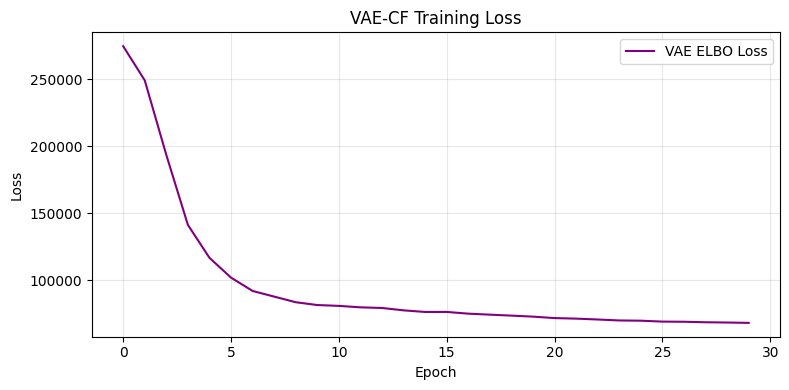

In [34]:
import matplotlib.pyplot as plt

# Loss 시각화
plt.figure(figsize=(8, 4))
plt.plot(vae_losses, color='purple', label='VAE ELBO Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VAE-CF Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **5-5. 추천 결과 확인**

In [35]:
vae.eval()
with torch.no_grad():
    h      = vae.encoder.layers(R_tensor)
    mu     = vae.encoder.mu_layer(h)
    recon  = vae.decoder(mu).cpu().numpy()

# NMF 추천 함수 재활용 (pred_df만 VAE 결과로 교체)
R_pred_vae = pd.DataFrame(recon, index=R_filled.index, columns=R_filled.columns)

print("\n=== NMF 추천 결과 (userId=1) ===")
nmf_result = recommend_movies(R_pred_nmf, R, userId=1, top_n=5).rename(columns={'pred_rating': '예측 평점 (1~5)'})
print(nmf_result.to_string(index=False))

print("\n=== VAE 추천 결과 (userId=1) ===")
vae_result = recommend_movies(R_pred_vae, R, userId=1, top_n=5).rename(columns={'pred_rating': '시청 확률 (0~1)'})
print(vae_result.to_string(index=False))


=== NMF 추천 결과 (userId=1) ===
                       title  예측 평점 (1~5)
       Close Shave, A (1995)     3.743240
             Heathers (1989)     3.606087
Sense and Sensibility (1995)     3.531067
          Stand by Me (1986)     3.471248
        Trainspotting (1996)     3.395183

=== VAE 추천 결과 (userId=1) ===
                            title  시청 확률 (0~1)
E.T. the Extra-Terrestrial (1982)     0.911367
                     Speed (1994)     0.795646
               Stand by Me (1986)     0.782394
                 True Lies (1994)     0.762158
          Schindler's List (1993)     0.758433


---
### 아래는 두 과제, A와 B 중 하나를 선택하셔서 수행하시면 됩니다! (물론 둘 다 해봐도 됩니다.)

---

## **6-A. SASRec - 어텐션 추천시스템 실습**

OTT나 이커머스처럼, 시청/구매 순서를 보고 다음 콘텐츠나 상품을 제안하는 추천 시스템을 생각해 보세요!

Transformer 기반 순차 추천에서는 **"미래 정보를 보면 안 된다"** 는 원칙이 있습니다.

예를 들어 `[신발, 바지, 셔츠, ?]` 시퀀스에서 `?`를 예측할 때,  
모델이 학습 중에 미래 아이템을 미리 보고 예측하면 의미가 없으니까요!

이번 실습에서는 MovieLens 100K 데이터로 SASRec을 직접 학습하고,  
**"같은 유저라도 어떤 시청 이력을 넣느냐에 따라 추천이 달라진다"** 는 것을 확인합니다.

In [36]:
import os, random, urllib.request, zipfile, io
import numpy as np
import pandas as pd
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42) # 시드 고정함

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')

사용 디바이스: cuda


### **Step 1. 데이터 로드 및 전처리**

MovieLens 100K를 로드합니다.
SASRec은 **"언제 봤는가"(즉 순서)** 가 중요하므로, timestamp 기준으로 정렬합니다.

- **Implicit feedback**: 평점 3점 이상 → 1 (봤다), 나머지 제외
- **ID 재매핑**: Embedding layer에 넣으려면 0~N-1 연속 id가 필요 (0은 padding 예약)

In [37]:
url = 'http://files.grouplens.org/datasets/movielens/ml-100k.zip'
with urllib.request.urlopen(url) as res:
    zf = zipfile.ZipFile(io.BytesIO(res.read()))

with zf.open('ml-100k/u.data') as f:
    df = pd.read_csv(f, sep='\t', names=['user', 'item', 'rating', 'timestamp'])

with zf.open('ml-100k/u.item') as f:
    item_meta = pd.read_csv(f, sep='|', encoding='latin-1', header=None, usecols=[0,1])
    item_meta.columns = ['item_raw', 'title']

df = df[df['rating'] >= 3]

user2id = {u: i+1 for i, u in enumerate(sorted(df['user'].unique()))}
item2id = {i: j+1 for j, i in enumerate(sorted(df['item'].unique()))}
df['user'] = df['user'].map(user2id)
df['item'] = df['item'].map(item2id)

n_users, n_items = df['user'].nunique(), df['item'].nunique()
print(f'유저 수: {n_users}, 아이템 수: {n_items}')

유저 수: 943, 아이템 수: 1574


### **Step 2. 유저별 시퀀스 생성 + Train/Val/Test 분할**

각 유저의 시청 이력을 시간순으로 정렬한 뒤 아래처럼 나눕니다.

| 분할 | 내용 |
|------|------|
| **train** | 전체 시퀀스에서 마지막 2개를 제외한 나머지 |
| **val** | 마지막에서 두 번째 아이템 |
| **test** | 마지막 아이템 |

In [38]:
df = df.sort_values(['user', 'timestamp'])

user_sequences = defaultdict(list)
for row in df.itertuples():
    user_sequences[row.user].append(row.item)

# 5개 미만 시청 유저 제거
user_sequences = {u: s for u, s in user_sequences.items() if len(s) >= 5}

user_train, user_val, user_test = {}, {}, {}
for u, seq in user_sequences.items():
    user_train[u] = seq[:-2]
    user_val[u]   = seq[-2]
    user_test[u]  = seq[-1]

print(f'학습 유저 수: {len(user_train)}')

학습 유저 수: 943


### **Step 3. Dataset 구성**

한 유저의 시퀀스 `[i1, i2, i3, i4]`로부터 아래처럼 학습 샘플을 만듭니다.

```
[i1]          → i2
[i1, i2]      → i3
[i1, i2, i3]  → i4
```

시퀀스 길이를 MAX_SEQ_LEN=50으로 고정하고, 짧은 경우 왼쪽을 0으로 패딩합니다.

In [39]:
MAX_SEQ_LEN = 50

class SASRecDataset(Dataset):
    def __init__(self, user_train_dict, max_len):
        self.seqs, self.targets = [], []
        for items in user_train_dict.values():
            if len(items) < 2:
                continue
            for t in range(1, len(items)):
                seq = items[:t][-max_len:]        # 최근 max_len개만 사용
                pad = [0] * (max_len - len(seq))  # 왼쪽 패딩
                self.seqs.append(pad + seq)
                self.targets.append(items[t])
        self.seqs    = torch.LongTensor(self.seqs)
        self.targets = torch.LongTensor(self.targets)

    def __len__(self): return len(self.targets)
    def __getitem__(self, idx): return self.seqs[idx], self.targets[idx]

train_dataset = SASRecDataset(user_train, MAX_SEQ_LEN)
train_loader  = DataLoader(train_dataset, batch_size=256, shuffle=True)
print(f'학습 샘플 수: {len(train_dataset)}')

학습 샘플 수: 79691


### **Step 4. SASRec 모델**

SASRec의 핵심은 **Causal Mask** 입니다.
현재 위치 t가 미래 위치(t+1, t+2, ...)를 보지 못하도록 상삼각 행렬로 막습니다.

```
위치:  0  1  2  3
  0  [ .  X  X  X ]   → 0번은 자신만 봄
  1  [ .  .  X  X ]   → 1번은 0, 1번만 봄
  2  [ .  .  .  X ]   → 2번은 0, 1, 2번만 봄
  3  [ .  .  .  . ]   → 3번은 전부 봄
X = 차단 (-inf 처리)
```

In [40]:
class SASRec(nn.Module):
    def __init__(self, n_items, d_model=64, n_layers=2, n_heads=2, max_len=50, dropout=0.2):
        super().__init__()
        self.item_emb = nn.Embedding(n_items+1, d_model, padding_idx=0)
        self.pos_emb  = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=4*d_model, dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(d_model)
        self.output  = nn.Linear(d_model, n_items+1, bias=False)
        self.output.weight = self.item_emb.weight  # weight tying

        nn.init.normal_(self.item_emb.weight, std=0.01)
        nn.init.normal_(self.pos_emb.weight,  std=0.01)

    def forward(self, seq):
        B, L = seq.shape
        pos  = torch.arange(L, device=seq.device).unsqueeze(0).expand(B, L)
        x    = self.norm(self.dropout(self.item_emb(seq) + self.pos_emb(pos)))

        # Causal mask: 상삼각 True → 미래 차단
        causal_mask = torch.triu(torch.ones(L, L, device=seq.device), diagonal=1).bool()
        pad_mask    = (seq == 0)

        h = self.encoder(x, mask=causal_mask, src_key_padding_mask=pad_mask)
        return h

    def predict_next(self, seq):
        # 마지막 위치의 hidden state로 다음 아이템 예측
        return self.output(self.forward(seq)[:, -1, :])

model = SASRec(n_items=n_items, d_model=128, n_layers=3, n_heads=4,
                max_len=MAX_SEQ_LEN, dropout=0.3).to(device)

### **Step 5. 평가 지표: Recall@K, NDCG@K**

| 지표 | 의미 |
|------|------|
| **Recall@K** | 정답 아이템이 Top-K 안에 들어있으면 1, 아니면 0 |
| **NDCG@K** | 정답 아이템의 순위가 높을수록 더 큰 점수 부여 |

In [41]:
def evaluate(model, user_train, user_eval, k=20):
    model.eval()
    recalls, ndcgs = [], []

    with torch.no_grad():
        for u, train_items in user_train.items():
            target = user_eval.get(u)
            if not target:
                continue

            seq = train_items[-MAX_SEQ_LEN:]
            seq = [0] * (MAX_SEQ_LEN - len(seq)) + seq
            seq_t = torch.LongTensor(seq).unsqueeze(0).to(device)

            scores = model.predict_next(seq_t).squeeze(0).cpu().numpy()
            scores[0] = -1e9
            for item in train_items:
                scores[item] = -1e9

            rank = int(np.where(np.argsort(-scores) == target)[0][0])
            recalls.append(1.0 if rank < k else 0.0)
            ndcgs.append(1.0 / np.log2(rank + 2) if rank < k else 0.0)

    print(f'Recall@{k}: {np.mean(recalls):.4f} | NDCG@{k}: {np.mean(ndcgs):.4f}')
    return np.mean(recalls), np.mean(ndcgs)

### **Step 6. 학습**

In [42]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

best_recall, best_state = 0.0, None
patience     = 10   # 성능 개선 없이 허용할 최대 epoch 수
no_improve   = 0    # 성능 개선 없는 epoch 카운트

for epoch in range(1, 51):
    model.train()
    total_loss = 0
    for seq_b, target_b in train_loader:
        seq_b, target_b = seq_b.to(device), target_b.to(device)
        loss = criterion(model.predict_next(seq_b), target_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * seq_b.size(0)

    print(f'[Epoch {epoch:2d}] 학습 손실: {total_loss/len(train_dataset):.4f}', end='  ')
    recall, _ = evaluate(model, user_train, user_val)

    if recall > best_recall:
        best_recall = recall
        best_state  = {k: v.cpu() for k, v in model.state_dict().items()}
        no_improve  = 0
        print('  ← best!')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'\n조기 종료: {patience}epoch 동안 성능 개선 없음')
            break

# best 모델 로드 후 최종 평가
model.load_state_dict(best_state)
model.to(device)
print('\n=== 최종 Test 성능 ===')
evaluate(model, user_train, user_test)

[Epoch  1] 학습 손실: 6.3739  Recall@20: 0.0976 | NDCG@20: 0.0390
  ← best!
[Epoch  2] 학습 손실: 5.8649  Recall@20: 0.1145 | NDCG@20: 0.0500
  ← best!
[Epoch  3] 학습 손실: 5.7607  Recall@20: 0.1220 | NDCG@20: 0.0522
  ← best!
[Epoch  4] 학습 손실: 5.6971  Recall@20: 0.1304 | NDCG@20: 0.0557
  ← best!
[Epoch  5] 학습 손실: 5.6446  Recall@20: 0.1315 | NDCG@20: 0.0501
  ← best!
[Epoch  6] 학습 손실: 5.5952  Recall@20: 0.1474 | NDCG@20: 0.0602
  ← best!
[Epoch  7] 학습 손실: 5.5522  Recall@20: 0.1336 | NDCG@20: 0.0533
[Epoch  8] 학습 손실: 5.5128  Recall@20: 0.1410 | NDCG@20: 0.0570
[Epoch  9] 학습 손실: 5.4809  Recall@20: 0.1379 | NDCG@20: 0.0601
[Epoch 10] 학습 손실: 5.4515  Recall@20: 0.1410 | NDCG@20: 0.0580
[Epoch 11] 학습 손실: 5.4250  Recall@20: 0.1432 | NDCG@20: 0.0584
[Epoch 12] 학습 손실: 5.4002  Recall@20: 0.1326 | NDCG@20: 0.0581
[Epoch 13] 학습 손실: 5.3757  Recall@20: 0.1485 | NDCG@20: 0.0580
  ← best!
[Epoch 14] 학습 손실: 5.3584  Recall@20: 0.1389 | NDCG@20: 0.0576
[Epoch 15] 학습 손실: 5.3373  Recall@20: 0.1379 | NDCG@20: 0.0592


(np.float64(0.13149522799575822), np.float64(0.05363110008171549))

### **Step 7. 추천 결과 확인**

같은 유저라도 **어떤 시청 이력을 입력하느냐에 따라 추천이 달라집니다.**
초반 이력만 넣었을 때와 전체 이력을 넣었을 때를 비교해봅시다.

In [43]:
# 내부 아이템 id → 영화 제목 매핑
id2raw   = {v: k for k, v in item2id.items()}
id2title = {inner: item_meta.set_index('item_raw').loc[raw, 'title']
            for inner, raw in id2raw.items()
            if raw in item_meta['item_raw'].values}

In [44]:
def recommend(seq, topk=10):
    model.eval()
    with torch.no_grad():
        s = seq[-MAX_SEQ_LEN:]
        s = [0] * (MAX_SEQ_LEN - len(s)) + s
        scores = model.predict_next(
            torch.LongTensor(s).unsqueeze(0).to(device)
        ).squeeze(0).cpu().numpy()
        scores[0] = -1e9
        for item in seq:
            scores[item] = -1e9
        return np.argsort(-scores)[:topk]

def compare_prefix(user_id, cut_ratio=0.5, topk=10):
    from IPython.display import display

    full = user_train[user_id]
    cut  = max(1, int(len(full) * cut_ratio))

    recent     = [id2title.get(i, f'item_{i}') for i in full[-10:]][::-1]
    early_recs = [id2title.get(i, f'item_{i}') for i in recommend(full[:cut], topk)]
    full_recs  = [id2title.get(i, f'item_{i}') for i in recommend(full, topk)]

    print(f'=== User {user_id} 최근 시청 ===')
    display(pd.DataFrame({
    '순서 (최근순)': range(1, len(recent)+1),
    '영화 제목': recent
    }).set_index('순서 (최근순)'))

    print(f'\n=== 초반 {cut}편 기준 vs 전체 {len(full)}편 기준 추천 비교 ===')
    display(pd.DataFrame({
    '순위': range(1, topk+1),
    f'초반 {cut}편 기준 추천': early_recs,
    f'전체 {len(full)}편 기준 추천': full_recs
    }).set_index('순위'))

In [45]:
# 실행하기

sample_user = list(user_train.keys())[10]
compare_prefix(sample_user, cut_ratio=0.4, topk=10)

=== User 11 최근 시청 ===


,영화 제목
순서 (최근순),
1,Benny & Joon (1993)
2,Pretty Woman (1990)
3,Shadowlands (1993)
4,"Room with a View, A (1986)"
5,Enchanted April (1991)
6,"Last of the Mohicans, The (1992)"
7,"Client, The (1994)"
8,Star Trek: The Motion Picture (1979)
9,Body Snatchers (1993)



=== 초반 62편 기준 vs 전체 156편 기준 추천 비교 ===


,초반 62편 기준 추천,전체 156편 기준 추천
순위,,
1,"Remains of the Day, The (1993)","Age of Innocence, The (1993)"
2,Field of Dreams (1989),Grease (1978)
3,"Piano, The (1993)","Bridges of Madison County, The (1995)"
4,"Graduate, The (1967)",Muriel's Wedding (1994)
5,Gandhi (1982),It Could Happen to You (1994)
6,Like Water For Chocolate (Como agua para choco...,Don Juan DeMarco (1995)
7,Quiz Show (1994),Dirty Dancing (1987)
8,Fried Green Tomatoes (1991),Legends of the Fall (1994)
9,Little Women (1994),How to Make an American Quilt (1995)


## **과제 6-B. 하이브리드 추천 시스템 아키텍처 설계**

> 여러분은 새로 출시하는 이커머스 플랫폼 **인사이트 쇼핑**의 추천 시스템 기획을 맡게 되었습니다.
> 아래 조건을 고려하여 추천 시스템 도입안을 작성하세요.
>
> - 컴퓨팅 자원이 한정되어 있어, 모든 작업을 딥러닝으로 처리하기는 어렵습니다.
> - 콜드 스타트 문제와 인기 편향 문제에 강건한 시스템이어야 합니다.

### **조건 1. 2단계 파이프라인 설계**

**1단계: 후보군 생성**

- **알고리즘**:  
- **이유**:

**2단계: 순위 매기기**

- **알고리즘**:
- **이유**:

### **조건 2. 콜드 스타트 대응**

**유저 콜드 스타트**


**아이템 콜드 스타드**


### **조건 3. 인기 편향 완화**

**발생 원인**

**완화 전략**

# 😊 수고하셨습니다 ~~~